In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

import os
os.chdir("/Users/miguel.vidal_ladivin/Desktop")

data = pd.read_csv("recursos_humanos.csv")

data_encoded = pd.get_dummies(data, columns=['sales', 'salary'], drop_first=True)

columna = "left"
columnas = [columna] + [col for col in data_encoded.columns if col != columna]
data_final= data_encoded[columnas]

R = data_final[data_final.left == 1]
NR = data_final[data_final.left == 0]

x = data_final.drop("left", axis=1)
y = data_final["left"]
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

df_resampled = pd.DataFrame(x_resampled, columns=x.columns)
df_resampled['left'] = y_resampled

R_resampled = df_resampled[df_resampled.left == 1]
NR_resampled = df_resampled[df_resampled.left == 0]



In [4]:
df_resampled["left"].value_counts(normalize=True)

left
1    0.5
0    0.5
Name: proportion, dtype: float64

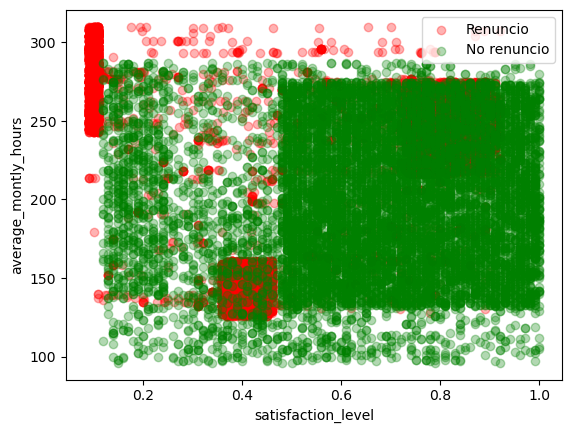

In [5]:
plt.scatter(R_resampled.satisfaction_level, R_resampled.average_montly_hours	, color="red", label="Renuncio", alpha=0.3)
plt.scatter(NR_resampled.satisfaction_level, NR_resampled.average_montly_hours	, color="green", label="No renuncio", alpha=0.3)
plt.xlabel("satisfaction_level")
plt.ylabel("average_montly_hours")
plt.legend()
plt.show()


In [6]:
NR_resampled

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,left
2000,0.58,0.74,4,215,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2001,0.82,0.67,2,202,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2002,0.45,0.69,5,193,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2003,0.78,0.82,5,247,3,0,0,False,False,False,False,False,False,True,False,False,True,False,0
2004,0.49,0.60,3,214,2,0,0,False,False,False,False,False,False,True,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14206,0.90,0.55,3,259,10,1,1,False,False,False,True,False,False,False,False,False,False,False,0
14207,0.74,0.95,5,266,10,0,1,False,False,False,True,False,False,False,False,False,False,False,0
14208,0.85,0.54,3,185,10,0,1,False,False,False,True,False,False,False,False,False,False,False,0
14209,0.33,0.65,3,172,10,0,1,False,False,False,False,True,False,False,False,False,False,False,0


In [7]:
y = df_resampled.left.values
x_resampled = df_resampled.drop(["left"], axis = 1)

x = (x_resampled - np.min(x_resampled)) / (np.max(x_resampled) - np.min(x_resampled))
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.001226,0.001710,0.006452,0.506452,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
1,0.002581,0.002774,0.016129,0.845161,0.019355,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.000000,0.003226
2,0.000355,0.002839,0.022581,0.877419,0.012903,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.000000,0.003226
3,0.002323,0.002806,0.016129,0.719355,0.016129,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
4,0.001194,0.001677,0.006452,0.512903,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.003226,0.000000,0.0,0.003226,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22851,0.000323,0.003161,0.019355,0.864516,0.012903,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.003226,0.0,0.003226,0.000000
22852,0.001293,0.003211,0.006452,0.893548,0.009677,0.0,0.0,0.003226,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.003226
22853,0.002486,0.003093,0.016129,0.716129,0.016129,0.0,0.0,0.000000,0.003226,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.003226,0.000000
22854,0.001344,0.001731,0.006452,0.467742,0.009677,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.003226,0.0,0.003226,0.000000


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split (x,y, test_size = 0.30, random_state = 1)


In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)

print("Score: ", knn.score(x_test, y_test))

Score:  0.9556657430363132


In [25]:
y_pred = prediction
y_true = y_test

In [28]:
from sklearn.metrics import confusion_matrix
cm =confusion_matrix(y_true, y_pred)
cm

array([[3138,  260],
       [  44, 3415]], dtype=int64)

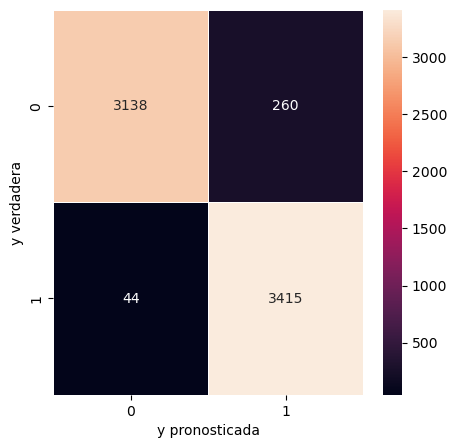

In [30]:
import seaborn as sns
f, ax = plt.subplots(figsize = (5,5))

sns.heatmap(cm, annot = True, linewidths = 0.5, color = "red", fmt = ".0f", ax = ax)
plt.xlabel ("y pronosticada")
plt.ylabel ("y verdadera")
plt.show()

In [32]:
correctos = cm[0,0] + cm[1,1]
incorrectos = cm[0,1] + cm[1,0]

precision_global = correctos / (correctos + incorrectos)
precision_global

0.9556657430363132

In [34]:
precisionbenigno = cm[0,0] / (cm[0,0] + cm[1,0])
precisionbenigno

0.9861722187303583

In [36]:
precisionmaligno = cm[1,1] / (cm[1,1] + cm[0,1])
precisionmaligno

0.9292517006802721

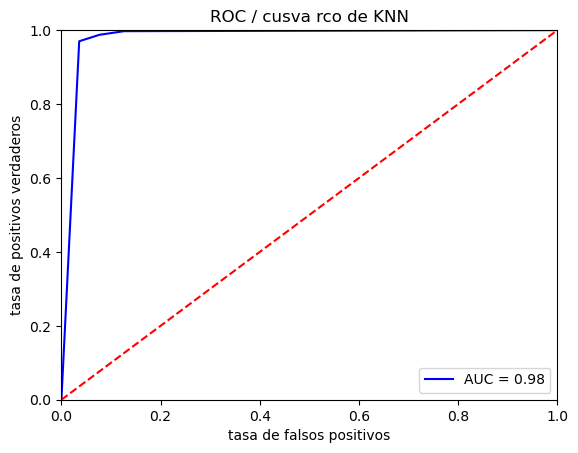

In [38]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1])
roc_auc = auc(fpr, tpr)

plt.title("receiver operating characterist")
plt.plot(fpr, tpr, "b", label= "AUC = %0.2f" % roc_auc)
plt.legend(loc="lower right")

plt.plot([0,1], [0,1], "r--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("tasa de positivos verdaderos")
plt.xlabel("tasa de falsos positivos")
plt.title("ROC / cusva rco de KNN")
plt.show()

In [17]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6857 entries, 9746 to 12156
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     6857 non-null   float64
 1   last_evaluation        6857 non-null   float64
 2   number_project         6857 non-null   float64
 3   average_montly_hours   6857 non-null   float64
 4   time_spend_company     6857 non-null   float64
 5   Work_accident          6857 non-null   float64
 6   promotion_last_5years  6857 non-null   float64
 7   sales_RandD            6857 non-null   float64
 8   sales_accounting       6857 non-null   float64
 9   sales_hr               6857 non-null   float64
 10  sales_management       6857 non-null   float64
 11  sales_marketing        6857 non-null   float64
 12  sales_product_mng      6857 non-null   float64
 13  sales_sales            6857 non-null   float64
 14  sales_support          6857 non-null   float64
 15  sales

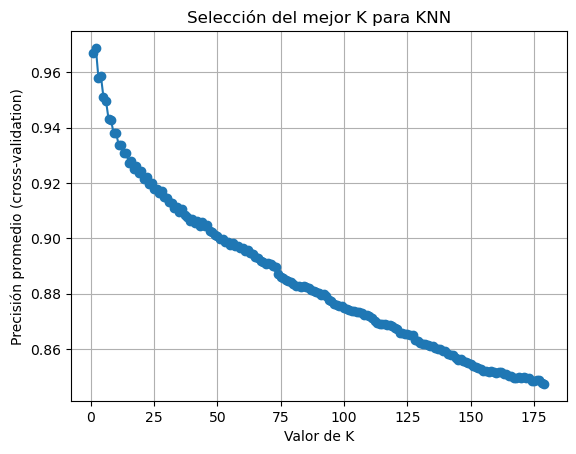

El mejor valor de K es: 2 con una precisión de 0.9688


In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Separar variables predictoras y objetivo
X = df_resampled.drop("left", axis=1)
y = df_resampled["left"]

# 2. Escalar los datos (muy importante en KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Probar distintos valores de k y guardar sus accuracies
k_range = range(1, 180)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    scores.append(cv_scores.mean())

# 4. Graficar los resultados
plt.plot(k_range, scores, marker='o')
plt.xlabel('Valor de K')
plt.ylabel('Precisión promedio (cross-validation)')
plt.title('Selección del mejor K para KNN')
plt.grid(True)
plt.show()

# 5. Mejor K
best_k = k_range[np.argmax(scores)]
print(f"El mejor valor de K es: {best_k} con una precisión de {max(scores):.4f}")

In [20]:
n = len(df_resampled)

import numpy as np

# 1. Calcular raíz cuadrada
k_est = int(np.sqrt(n))

# 2. Asegurar que sea impar
if k_est % 2 == 0:
    k_est += 1

print(f"Valor estimado inicial de k: {k_est}")

Valor estimado inicial de k: 151


In [22]:
data_encoded["left"].value_counts(normalize=True)

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64